# Figure 6 — Monthly vertical biases relative to ERA5

Latitude–pressure sections of zonal-mean **experiment − ERA5** biases in U, V, T, Q.
All selected experiments, including CTRL, are compared with ERA5 for the analysis
months. ERA5 is loaded from `ERA5_PATH`; its regular 1° lat/lon grid must match
the model grid exactly. Only requested fields and months are read lazily.

ERA5 standard pressure levels are selected directly; model fields are interpolated
when needed to `PRESSURE_LEVELS` (1000–1 hPa) before paired finite differences
are averaged over longitude. ERA5 surface pressure and each
model's surface pressure mask below-ground values. No vertical extrapolation is
performed. Model files may already use pressure levels or require hybrid metadata.

`PLOT_MONTH=None` gives a mean weighted by ERA5 calendar month lengths (29 days
in February 2012); YYYYMM selects one month. Months are matched by year/month
across the Gregorian ERA5 and no-leap model calendars. Q is cached in kg/kg and
displayed in g/kg. Color scales are shared across experiments for each variable.

Model inputs prefer monthly time series, with exact single-month climo files as a
fallback. ERA5 outputs have separate cache directories and figure names, preserving
previous nudged-reference results. Cached signatures include the ERA5 path; use
`FORCE_COMPUTE=True` if the contents of input files change at the same paths.

Each panel annotates RMSE and spatial PCC between its displayed experiment and
ERA5 mean sections, using cos(latitude) × pressure-layer thickness weights over
paired finite cells. These are statistics of the monthly or period-mean sections,
not daily RMSE or temporal correlation. Q RMSE uses g/kg, matching the colorbar.


## 1. Settings and per-case cache checks


In [23]:
from pathlib import Path
import importlib
import json
import sys
import numpy as np
import xarray as xr
import dask
from dask.distributed import Client, get_client

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError('Run from ml_implement_paper/ or its notebooks/ directory')
sys.path.insert(0, str(PROJECT_ROOT))

from src import io as data_io
from src import metrics, plotting, preprocessing
from src import monthly_bias
plotting = importlib.reload(plotting)
monthly_bias = importlib.reload(monthly_bias)

config = data_io.load_config(PROJECT_ROOT / 'config' / 'paths.yaml')
analysis = config['analysis']

# ------------------------- User-adjustable settings -------------------------
OUTPUT_ROOT = Path('/global/cfs/cdirs/e3sm/www/zhan391/sea_crogs/online_diag')
ML_ROOT = Path('/pscratch/sd/z/zhan391/seacrogs_scratch/ml_method_2026')
ERA5_PATH = Path('/global/cfs/cdirs/e3sm/zhan391/data/ERA5/process_monthly/monthly/ERA5_analysis_monthly_1979-2019_1x1.nc')
REFERENCE_LABEL = 'ERA5'
POST_SUBDIR = Path('post/atm/180x360_aave/ts/monthly/1yr')
CLIMO_SUBDIR = Path('post/atm/180x360_aave/clim/1yr')
PERIOD = '201201_201212'
FORCE_COMPUTE = False  # True: overwrite selected case caches.
# Select cases here; comment out any experiment you do not want to plot.
CASE_DIRS = {
    'CTRL': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_CTRL',
    'UNET-IMT': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNET_IMT_NS6_WOQMADJ_WOTVCON_PBL222_WOVSMOOTH',
    'UNETXTR-IMT': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_IMT_NS6_WOQMADJ_WOTVCON_PBL222_WOVSMOOTH',
    'UNETXTR-IMT-A15': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_IMT_NS6_WQMADJ_WTVCON_PBL222_WVSMOOTH-S0.15',
    'UNETXTR-IMT-C05': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_IMT_NS6_SCL0.5_WOQMADJ_WOTVCON_PBL222_WOVSMOOTH',
    'UNETXTR-IMT-C05A15': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_IMT_NS6_SCL0.5_WQMADJ_WTVCON_PBL222_WVSMOOTH-S0.15',
    'UNETXTR-LCZ-C05A15': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_LANCZOS_NS6_SCL0.5_WQMADJ_WTVCON_PBL222_WVSMOOTH-S0.15',
    'UNETXTR-LCZ-C05A15-PTAP100': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_LANCZOS_NS6_SCL0.5_PTAPUNI100HPA_WQMADJ_WTVCON_PBL222_WVSMOOTH-S0.15',
}
REQUIRED_VARIABLES = ['U', 'V', 'T', 'Q']
# Extend Figure 6 into the stratosphere without changing the other figures.
PRESSURE_LEVELS = sorted(set(analysis['pressure_levels_hpa']) | {70, 50, 30, 20, 10, 5, 1}, reverse=True)
LEVEL_DIM = analysis['level_dimension']
PRESSURE_NAME = analysis['pressure_coordinate']
HYBRID_NAMES = analysis['hybrid_pressure']
# None: day-weighted period mean; YYYYMM (e.g. 201201): one month.
PLOT_MONTH = None
# Colorbar ranges are set in the final plotting cell.
PRESSURE_SCALE = 'log'
FONT_SIZE = 12
FIGURE_SIZE = None  # Automatically sized to the selected cases.

if not CASE_DIRS:
    raise ValueError('Select at least one experiment')
ANALYSIS_CASES = tuple(name for name in CASE_DIRS if name != 'REF')
DIAGNOSTIC_DIR = OUTPUT_ROOT / 'processed' / 'monthly_vertical_bias' / REFERENCE_LABEL
DIAGNOSTIC_PATHS = {name: DIAGNOSTIC_DIR / f'{name}_{PERIOD}.nc' for name in ANALYSIS_CASES}

def cache_signature(case):
    return json.dumps({
        'version': 5, 'case': str(CASE_DIRS[case]), 'reference': str(ERA5_PATH),
        'reference_label': REFERENCE_LABEL, 'calendar_weighting': 'ERA5 days per month',
        'post_subdir': str(POST_SUBDIR), 'climo_subdir': str(CLIMO_SUBDIR), 'period': PERIOD,
        'start': analysis['start_date'], 'end': analysis['end_date'],
        'variables': REQUIRED_VARIABLES, 'levels': PRESSURE_LEVELS,
        'level_dim': LEVEL_DIM, 'pressure_name': PRESSURE_NAME, 'hybrid': HYBRID_NAMES,
    }, sort_keys=True)

def cache_is_compatible(path, case):
    if not path.exists():
        return False
    try:
        with xr.open_dataset(path) as cached:
            return (cached.attrs.get('cache_signature') == cache_signature(case)
                    and {field for variable in REQUIRED_VARIABLES
                         for field in (variable, f'{variable}_model', f'{variable}_reference')}.issubset(cached.data_vars)
                    and {'month', 'plev', 'lat', 'experiment'}.issubset(cached.dims)
                    and cached.sizes['month'] > 0 and 'days_in_month' in cached.coords
                    and list(cached.experiment.values) == [case]
                    and np.array_equal(cached.plev.values, PRESSURE_LEVELS))
    except (KeyError, OSError, ValueError):
        return False

CASES_TO_COMPUTE = tuple(case for case in ANALYSIS_CASES
                         if FORCE_COMPUTE or not cache_is_compatible(DIAGNOSTIC_PATHS[case], case))
RECOMPUTE = bool(CASES_TO_COMPUTE)
if RECOMPUTE:
    try:
        client = get_client()
    except ValueError:
        client = Client(n_workers=4, threads_per_worker=1, processes=False, dashboard_address=':0')
print({'mode': 'compute' if RECOMPUTE else 'cached', 'cases': CASES_TO_COMPUTE})


{'mode': 'cached', 'cases': ()}


## 2. Load and quality-check monthly fields


In [24]:
# Prefer monthly time series; use exact single-month climo files if incomplete.
# Both modes must already be remapped to the common latitude/longitude grid.
datasets = {}
if RECOMPUTE:
    datasets['REF'] = monthly_bias.open_era5_monthly(
        ERA5_PATH, REQUIRED_VARIABLES, analysis['start_date'], analysis['end_date'],
        chunks={'time': 1, 'lat': 45, 'lon': 90},
    )
    print(f'REF: {REFERENCE_LABEL} ({ERA5_PATH})', flush=True)
for case in CASES_TO_COMPUTE:
    datasets[case] = monthly_bias.open_monthly_fields(
        CASE_DIRS[case], POST_SUBDIR, CLIMO_SUBDIR, PERIOD, REQUIRED_VARIABLES,
        analysis['start_date'], analysis['end_date'], hybrid_names=HYBRID_NAMES,
        pressure_name=PRESSURE_NAME, chunks={'time': 1, 'lat': 45, 'lon': 90},
    )
    print(f"{case}: {datasets[case].attrs['monthly_input_mode']}", flush=True)

# Require the same complete month list and horizontal grid, avoiding cache-dependent periods.
if RECOMPUTE:
    start = analysis['start_date'][:7]
    end = analysis['end_date'][:7]
    expected_months = np.arange(np.datetime64(start, 'M'), np.datetime64(end, 'M') + 1)
    expected_months = np.array([int(str(m).replace('-', '')) for m in expected_months])
    for case, ds in datasets.items():
        if not np.array_equal(ds.month.values, expected_months):
            raise ValueError(f'{case}: monthly files do not cover every requested month')
        for coordinate in ('lat', 'lon'):
            if not ds[coordinate].equals(datasets['REF'][coordinate]):
                raise ValueError(f'{case}: {coordinate} grid differs from REF; remap first')

qc_keys, qc_tasks = [], []
for case, ds in datasets.items():
    for variable in REQUIRED_VARIABLES:
        qc_keys.append((case, variable))
        qc_tasks.extend([np.isfinite(ds[variable]).any().data,
                         (~np.isfinite(ds[variable])).sum().data])
qc_values = dask.compute(*qc_tasks)
qc = {}
for i, (case, variable) in enumerate(qc_keys):
    if not bool(qc_values[2 * i]):
        raise ValueError(f'{case}:{variable} has no finite values')
    qc.setdefault(case, {})[variable] = int(qc_values[2 * i + 1])
qc


{}

## 3. Derive and save monthly zonal-mean biases


In [25]:
if RECOMPUTE:
    def to_pressure(ds):
        return monthly_bias.pressure_fields(
            ds, REQUIRED_VARIABLES, PRESSURE_LEVELS, level_dim=LEVEL_DIM,
            pressure_name=PRESSURE_NAME, hybrid_names=HYBRID_NAMES,
        )

    # Select ERA5's existing standard levels directly; no interpolation is needed.
    reference = monthly_bias.select_era5_pressure(
        datasets['REF'], REQUIRED_VARIABLES, PRESSURE_LEVELS,
    )
    for case in CASES_TO_COMPUTE:
        # Use REF calendar month lengths consistently for all experiments.
        model = to_pressure(datasets[case]).assign_coords(days_in_month=reference.days_in_month)
        product = monthly_bias.zonal_comparison(model, reference, REQUIRED_VARIABLES)
        product.attrs['bias_definition'] = 'experiment minus ERA5; paired finite longitude mean'
        for variable in REQUIRED_VARIABLES:
            product[variable].attrs['long_name'] = f'{variable} zonal-mean bias (experiment minus ERA5)'
        product = product.expand_dims(experiment=[case]).compute()
        for variable in REQUIRED_VARIABLES:
            if not bool(np.isfinite(product[variable]).any()):
                raise ValueError(f'{case}:{variable} has no finite pressure-level biases')
        product.attrs.update(cache_signature=cache_signature(case), period=PERIOD,
                             reference_case=str(ERA5_PATH), reference_label=REFERENCE_LABEL,
                             temporal_weighting='ERA5 calendar days per month',
                             panel_statistics='RMSE and spatial PCC of displayed zonal-mean fields; cos(latitude) times pressure-layer thickness weights',
                             experiment_input_mode=datasets[case].attrs['monthly_input_mode'],
                             experiment_input_files=datasets[case].attrs['monthly_input_files'],
                             reference_input_mode=datasets['REF'].attrs['monthly_input_mode'],
                             reference_input_files=datasets['REF'].attrs['monthly_input_files'])
        data_io.save_dataset(product, DIAGNOSTIC_PATHS[case])
    for ds in datasets.values():
        ds.close()

print({case: str(path) for case, path in DIAGNOSTIC_PATHS.items()})


{'CTRL': '/global/cfs/cdirs/e3sm/www/zhan391/sea_crogs/online_diag/processed/monthly_vertical_bias/ERA5/CTRL_201201_201212.nc', 'UNET-IMT': '/global/cfs/cdirs/e3sm/www/zhan391/sea_crogs/online_diag/processed/monthly_vertical_bias/ERA5/UNET-IMT_201201_201212.nc', 'UNETXTR-IMT': '/global/cfs/cdirs/e3sm/www/zhan391/sea_crogs/online_diag/processed/monthly_vertical_bias/ERA5/UNETXTR-IMT_201201_201212.nc', 'UNETXTR-IMT-A15': '/global/cfs/cdirs/e3sm/www/zhan391/sea_crogs/online_diag/processed/monthly_vertical_bias/ERA5/UNETXTR-IMT-A15_201201_201212.nc', 'UNETXTR-IMT-C05': '/global/cfs/cdirs/e3sm/www/zhan391/sea_crogs/online_diag/processed/monthly_vertical_bias/ERA5/UNETXTR-IMT-C05_201201_201212.nc', 'UNETXTR-IMT-C05A15': '/global/cfs/cdirs/e3sm/www/zhan391/sea_crogs/online_diag/processed/monthly_vertical_bias/ERA5/UNETXTR-IMT-C05A15_201201_201212.nc', 'UNETXTR-LCZ-C05A15': '/global/cfs/cdirs/e3sm/www/zhan391/sea_crogs/online_diag/processed/monthly_vertical_bias/ERA5/UNETXTR-LCZ-C05A15_201201_

## 4. Reload the diagnostic and plot


PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/sea_crogs/online_diag/figures/fig06_monthly_vertical_bias_ERA5_201201_201212_period_mean.png')

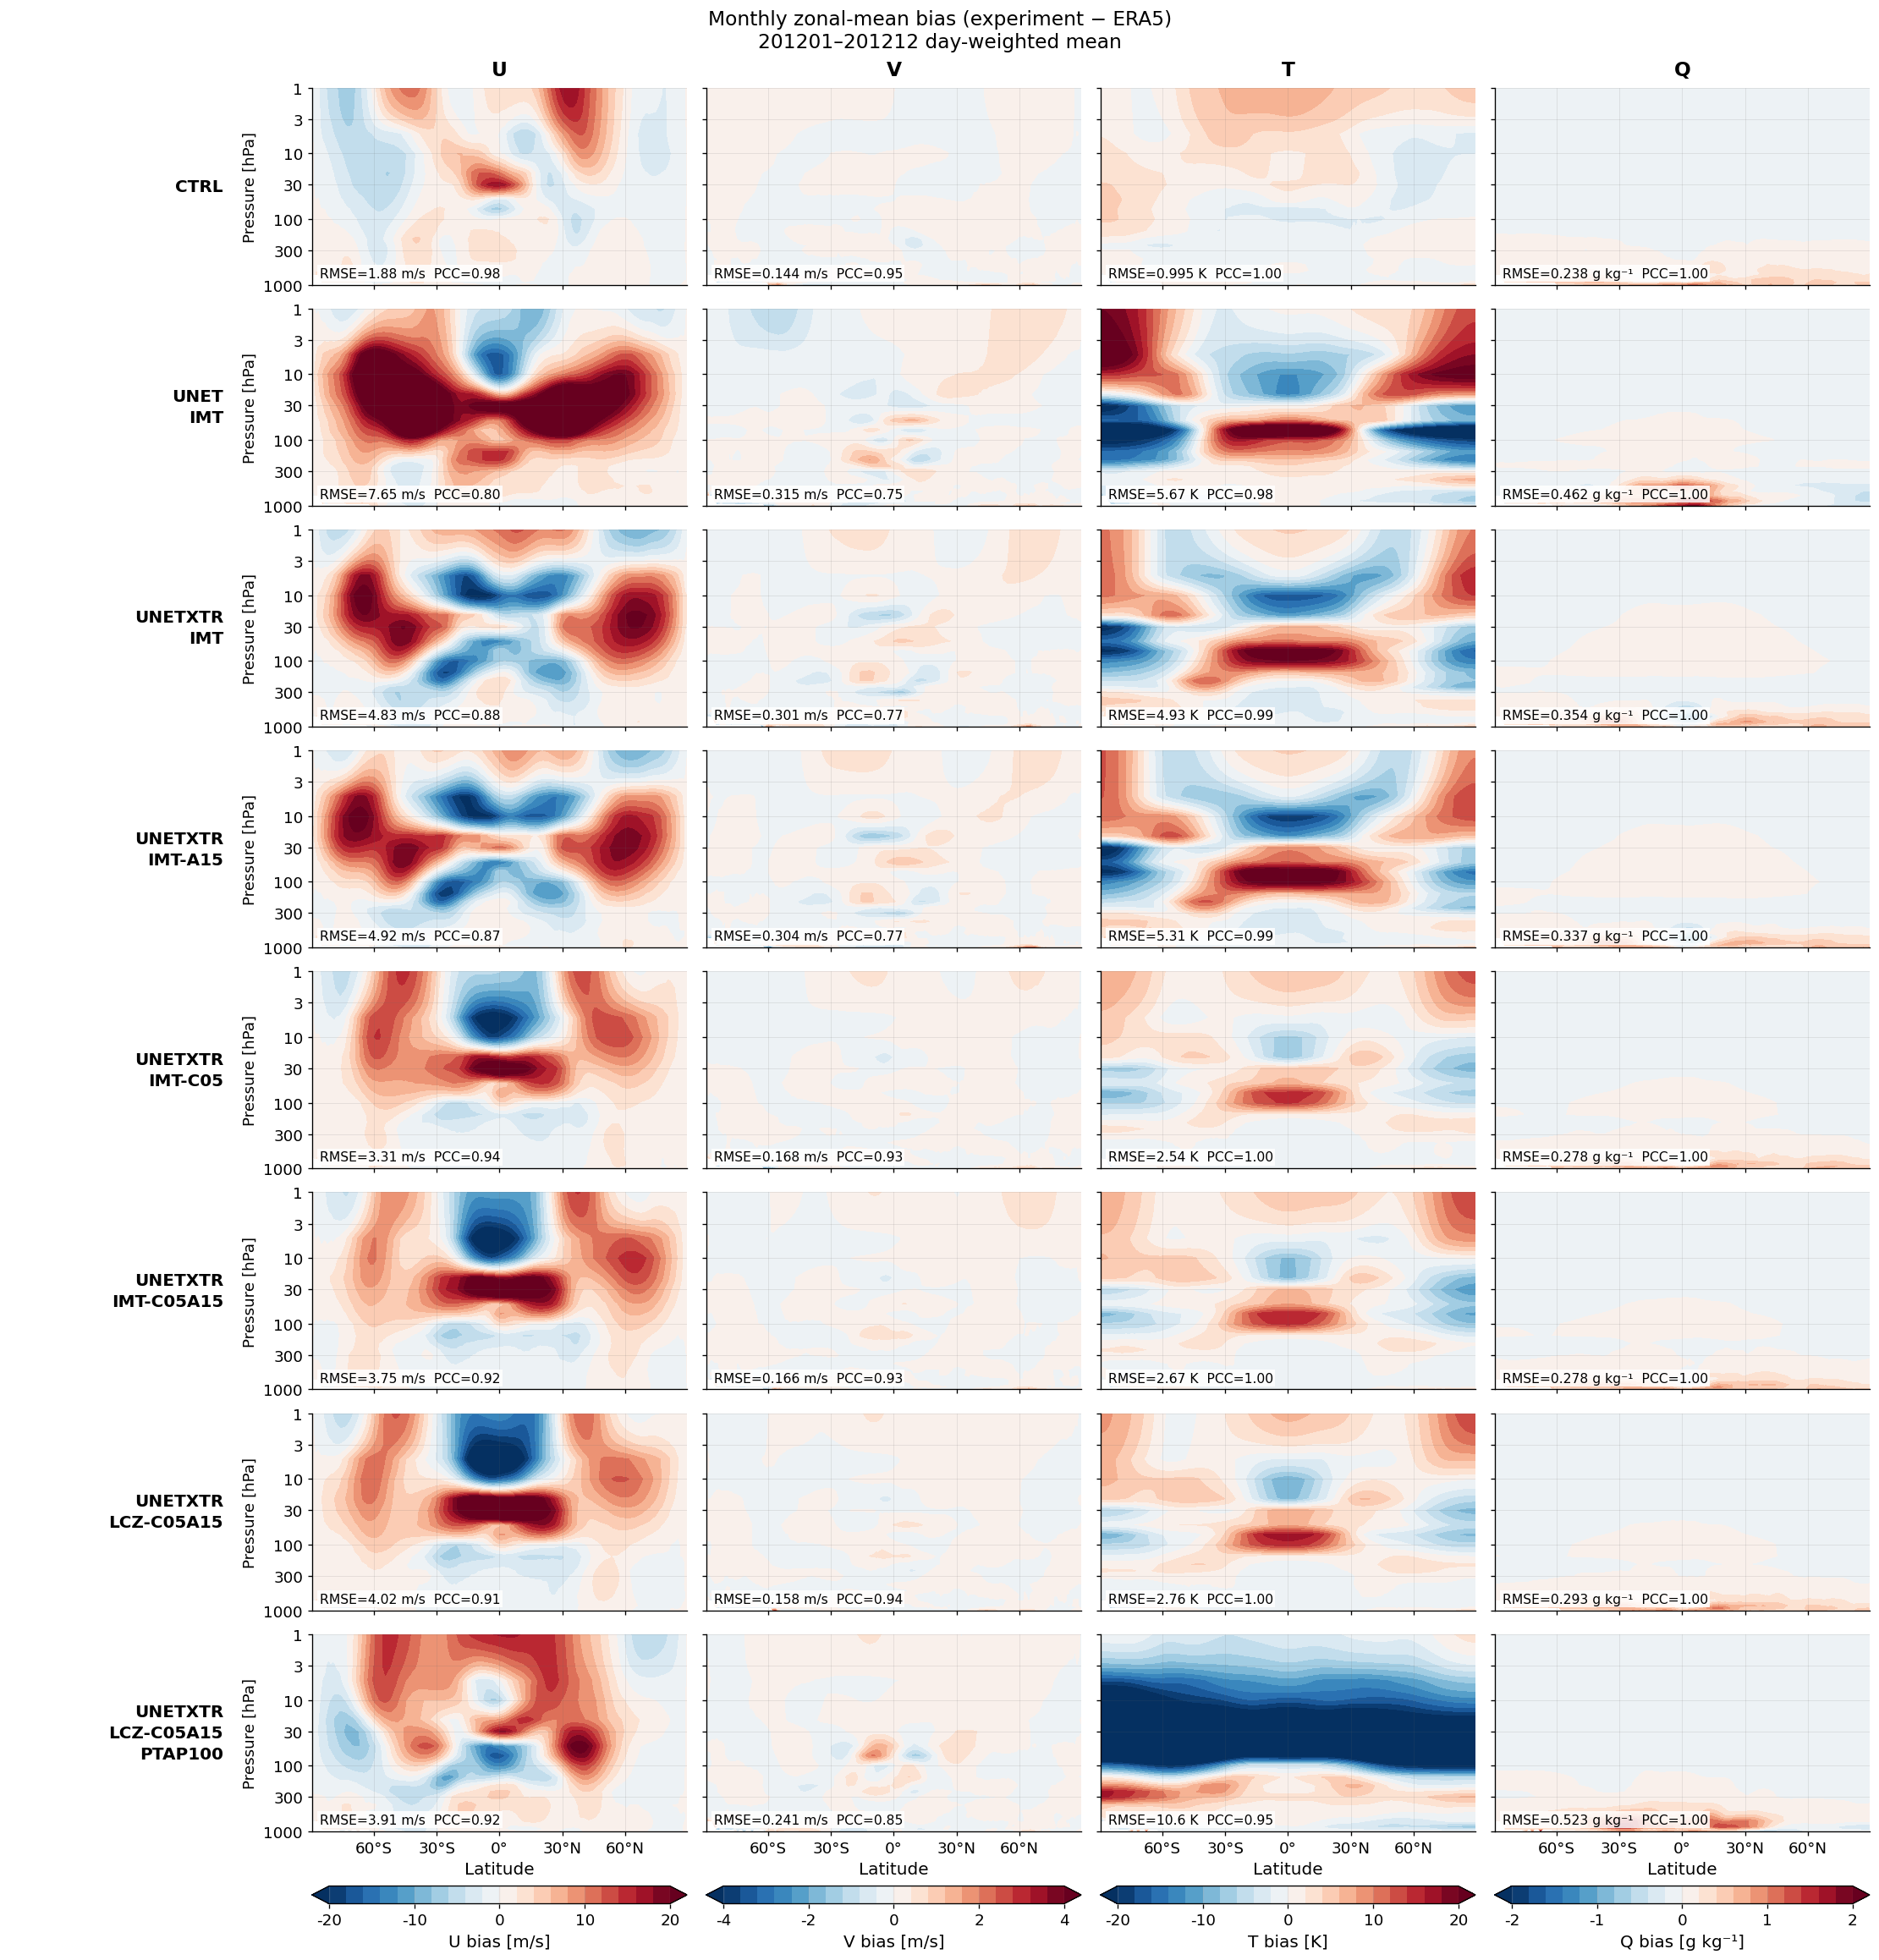

In [26]:
# ------------------------- User-adjustable colorbar ranges ------------------
# Each number is the positive limit: the range is [-limit, +limit].
# These limits are shared across cases. Values beyond them use the end colors.
# Remove a variable from this dictionary to use its automatic range.
COLOR_LIMITS = {
    'U': 20.0,  # -20 to +20 m/s
    'V': 4.0,   # -4 to +4 m/s
    'T': 20.0,  # -20 to +20 K
    'Q': 2.0,   # -2 to +2 g/kg (display units)
}
# ---------------------------------------------------------------------------

# Reload the plot helper and small caches; layout changes need no recomputation.
plotting = importlib.reload(plotting)
products = []
for case in ANALYSIS_CASES:
    with xr.open_dataset(DIAGNOSTIC_PATHS[case]) as cached:
        products.append(cached.load())
diagnostic = xr.concat(products, dim='experiment', join='exact',
                       coords='minimal', compat='equals', combine_attrs='drop_conflicts')
suffix = 'period_mean' if PLOT_MONTH is None else str(PLOT_MONTH)
FIGURE_PATH = OUTPUT_ROOT / 'figures' / f'fig06_monthly_vertical_bias_{REFERENCE_LABEL}_{PERIOD}_{suffix}.png'
plotting.plot_monthly_vertical_bias(
    diagnostic, FIGURE_PATH, variables=REQUIRED_VARIABLES, month=PLOT_MONTH,
    color_limits=COLOR_LIMITS, pressure_scale=PRESSURE_SCALE,
    font_size=FONT_SIZE, figsize=FIGURE_SIZE,
)
